# Module 2: Supercapacitor Charge / Discharge Model

**GhostBreath – Self-Powered Cognitive Fatigue Monitor**  
Embedded Systems Course Project · March 2026

---

## Objective
Model the supercapacitor (EDLC) energy buffer between the TEG harvest stage
and the CO₂ sensor + MCU load. Determine:

1. **Minimum supercapacitor size** (capacitance) to sustain operation
2. **Charge time** from empty to operational for each TEG power level
3. **Maximum sustainable duty cycle** (measurement frequency) for each P_in
4. **State of charge** over time — voltage trajectory plots

## System Architecture

```
Laptop exhaust heat
       │
       ▼
  [ TEC1-12706 TEG ]  ← Module 1: ΔT_teg = η_th × ΔT_source
       │ V_oc, P_max
       ▼
  [ BQ25570 Boost ]   ← η_boost = 80 %
       │ P_in = P_boost
       ▼
  [ Supercapacitor ]  ← THIS MODULE
    1 F EDLC, 2.7 V
       │
       ▼
  [ 3.3 V LDO/Boost ]
       │
   ┌───┴───┐
   │       │
[SCD41] [ESP32-C3]   ← CO₂ sensor + MCU (duty-cycled)
```

## Supercapacitor Parameters

| Parameter | Symbol | Value | Source |
|-----------|--------|-------|--------|
| Capacitance | C | 1 F | Murata JUWT1105MCD |
| Max voltage | V_max | 2.7 V | Datasheet |
| Min voltage | V_min | 1.0 V | BQ25570 cold-start threshold |
| ESR | R_ESR | 50 mΩ | Datasheet typ. |
| Usable energy | E | ≈ 3.14 J | 0.5·C·(V_max²−V_min²) |

## TEG Input Power (from Module 1, realistic coupling)

Using **η_th = 40–60 %** thermal coupling (clip-on device):

| ΔT_source | P_boost (η_th=40%) | P_boost (η_th=50%) | P_boost (η_th=60%) |
|-----------|-------------------|-------------------|-------------------|
| 10 °C | 1.72 mW | 2.69 mW | 3.87 mW |
| 15 °C | 3.87 mW | 6.05 mW | 8.71 mW |
| 20 °C | 6.88 mW | 10.75 mW | 15.48 mW |
| 25 °C | 10.75 mW | 16.80 mW | 24.19 mW |

## Physics

Constant-power charging/discharging of a capacitor:

$$C \cdot V \cdot \frac{dV}{dt} = P_{net} \implies V(t) = \sqrt{V_0^2 + \frac{2 P_{net} t}{C}}$$

Charge/discharge time:

$$t = \frac{C (V_b^2 - V_a^2)}{2 P}$$

## Reference
- Prickett & Davis (2019), *Supercapacitor energy storage for IoT edge devices*
- Texas Instruments BQ25570 datasheet

---
## Setup: Imports and Style

In [1]:
import sys
import os

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

sys.path.insert(0, os.path.abspath('.'))

from utils.supercap_model import (
    usable_energy,
    min_capacitance,
    charge_time,
    discharge_time,
    voltage_vs_time_charge,
    voltage_vs_time_discharge,
    system_power_W,
    min_period_for_power,
    simulate,
    duty_cycle_analysis,
    DEFAULT_SUPERCAP,
    SYSTEM_LOAD,
    P_MIN_MW,
)
from utils.teg_model import (
    boost_output_power,
    max_power,
    realistic_teg_power,
    REALISTIC_THERMAL_PARAMS,
)

os.makedirs('figures', exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

C_BLUE   = '#1f77b4'
C_ORANGE = '#ff7f0e'
C_GREEN  = '#2ca02c'
C_RED    = '#d62728'
C_PURPLE = '#9467bd'
C_GRAY   = '#7f7f7f'

print(f"NumPy {np.__version__}  |  Matplotlib {matplotlib.__version__}")
print("Supercap defaults:", DEFAULT_SUPERCAP)
print("TEG realistic thermal params:", REALISTIC_THERMAL_PARAMS)

NumPy 2.4.2  |  Matplotlib 3.10.8
Supercap defaults: {'C_sc': 1.0, 'V_max': 2.7, 'V_min': 1.0, 'ESR': 0.05}
TEG realistic thermal params: {'R_contact_hot': 2.0, 'R_hs': 1.0}


---
## Step 1 — Define Parameters

In [2]:
# ── Supercapacitor ─────────────────────────────────────────────────────────────
C_sc  = DEFAULT_SUPERCAP['C_sc']    # 1 F
V_max = DEFAULT_SUPERCAP['V_max']   # 2.7 V
V_min = DEFAULT_SUPERCAP['V_min']   # 1.0 V
ESR   = DEFAULT_SUPERCAP['ESR']     # 50 mΩ

# ── TEG electrical params (Module 1) ──────────────────────────────────────────
N       = 127
alpha   = 200e-6    # V/K
R_int   = 1.2       # Ω
eta_boost = 0.80

# ── Thermal coupling (realistic) ──────────────────────────────────────────────
COUPLING_LO  = 0.40
COUPLING_MID = 0.50
COUPLING_HI  = 0.60

# ── System supply ─────────────────────────────────────────────────────────────
V_sys = SYSTEM_LOAD['V_sys']   # 3.3 V

# ── Usable energy ─────────────────────────────────────────────────────────────
E_use_J  = usable_energy(C_sc, V_max, V_min)
E_use_mJ = E_use_J * 1e3

print("TEC1-12706 + BQ25570 TEG harvester:")
print(f"  N={N}, α={alpha*1e6:.0f} µV/K, R_int={R_int} Ω, η_boost={eta_boost*100:.0f}%")
print(f"  Thermal coupling: {COUPLING_LO*100:.0f}–{COUPLING_HI*100:.0f}% (nominal {COUPLING_MID*100:.0f}%)")
print()
print(f"Supercapacitor:")
print(f"  C = {C_sc} F,  V_max = {V_max} V,  V_min = {V_min} V,  ESR = {ESR*1000:.0f} mΩ")
print(f"  Usable energy E = 0.5×C×(V_max²−V_min²) = {E_use_J:.4f} J  = {E_use_mJ:.2f} mJ")
print()
print(f"System supply: {V_sys} V")
print(f"Min system power budget: {P_MIN_MW} mW")

TEC1-12706 + BQ25570 TEG harvester:
  N=127, α=200 µV/K, R_int=1.2 Ω, η_boost=80%
  Thermal coupling: 40–60% (nominal 50%)

Supercapacitor:
  C = 1.0 F,  V_max = 2.7 V,  V_min = 1.0 V,  ESR = 50 mΩ
  Usable energy E = 0.5×C×(V_max²−V_min²) = 3.1450 J  = 3145.00 mJ

System supply: 3.3 V
Min system power budget: 0.5 mW


In [3]:
# ── TEG Input Power (from Module 1 realistic boost output) ────────────────────
# These values are computed by realistic_teg_power() — the same function used
# in Module 1's final summary — and feed directly into the supercapacitor model.
#
# Formula: P_boost = η_boost × (N × α × η_th × ΔT_src)² / (4 × R_int)
#   η_th = 40–60% (thermal coupling, clip-on device; R_contact_hot=2 K/W, R_hs=1 K/W)
# ─────────────────────────────────────────────────────────────────────────────
DT_VALS = [10, 15, 20, 25]

print("=" * 62)
print("TEG Input Power (from Module 1 realistic boost output)")
print("=" * 62)
print(f"  TEG   : TEC1-12706  N={N}, alpha={alpha*1e6:.0f} uV/K, R_int={R_int} Ohm")
print(f"  Boost : eta_boost = {eta_boost*100:.0f}%  (BQ25570 converter)")
print(f"  eta_th: {COUPLING_LO*100:.0f}% (worst) / {(COUPLING_LO+COUPLING_HI)/2*100:.0f}% (nominal) / {COUPLING_HI*100:.0f}% (best)")
print()
print(f"  {'DT_source':>10}  {'P_boost 40%':>12}  {'P_boost 50%':>12}  {'P_boost 60%':>12}")
print(f"  {'(C)':>10}  {'(mW)':>12}  {'(mW)':>12}  {'(mW)':>12}")
print("  " + "-" * 52)

teg_power_table = {}
for dt in DT_VALS:
    rp = realistic_teg_power(dt,
                              coupling_lo=COUPLING_LO,
                              coupling_hi=COUPLING_HI,
                              N=N, alpha=alpha, R_int=R_int,
                              eta_boost=eta_boost)
    p_lo  = rp["P_boost_lo_mW"]
    p_mid = rp["P_boost_mid_mW"]
    p_hi  = rp["P_boost_hi_mW"]
    teg_power_table[dt] = {"lo": p_lo, "mid": p_mid, "hi": p_hi}
    print(f"  {dt:>9}C  {p_lo:>12.2f}  {p_mid:>12.2f}  {p_hi:>12.2f}")

print("  " + "=" * 52)
print()
print("These P_boost values are used as P_in throughout Module 2:")
print("  - Charge time analysis (Step 3)")
print("  - Duty-cycle analysis (Step 4)")
print("  - Time-domain voltage simulation (Step 6)")
print()
# Nominal operating point referenced in subsequent cells
P_IN_NOM_W = teg_power_table[15]["mid"] * 1e-3   # W, DT=15C, 50%
P_IN_LO_W  = teg_power_table[15]["lo"]  * 1e-3   # W, DT=15C, 40%  (worst at DT=15)
print(f"  Nominal (DT=15C, 50%): P_in = {P_IN_NOM_W*1e3:.2f} mW")
print(f"  Worst   (DT=10C, 40%): P_in = {teg_power_table[10]['lo']:.2f} mW")


TEG Input Power (from Module 1 realistic boost output)
  TEG   : TEC1-12706  N=127, alpha=200 uV/K, R_int=1.2 Ohm
  Boost : eta_boost = 80%  (BQ25570 converter)
  eta_th: 40% (worst) / 50% (nominal) / 60% (best)

   DT_source   P_boost 40%   P_boost 50%   P_boost 60%
         (C)          (mW)          (mW)          (mW)
  ----------------------------------------------------
         10C          1.72          2.69          3.87
         15C          3.87          6.05          8.71
         20C          6.88         10.75         15.48
         25C         10.75         16.80         24.19

These P_boost values are used as P_in throughout Module 2:
  - Charge time analysis (Step 3)
  - Duty-cycle analysis (Step 4)
  - Time-domain voltage simulation (Step 6)

  Nominal (DT=15C, 50%): P_in = 6.05 mW
  Worst   (DT=10C, 40%): P_in = 1.72 mW


---
## Step 2 — System Load Power vs. Measurement Period

The SCD41 CO₂ sensor and ESP32-C3 MCU are **duty-cycled** to minimise average power.
One "session" per period T consists of:

1. **Measurement** (5 s): SCD41 single-shot @ 3.3 mA + MCU sleep @ 5 µA  
2. **BLE transmit** (0.2 s): MCU active @ 80 mA + SCD41 idle @ 40 µA  
3. **Sleep** (T − 5.2 s): both in deep sleep  

Longer T → lower average power → achievable with less TEG output.

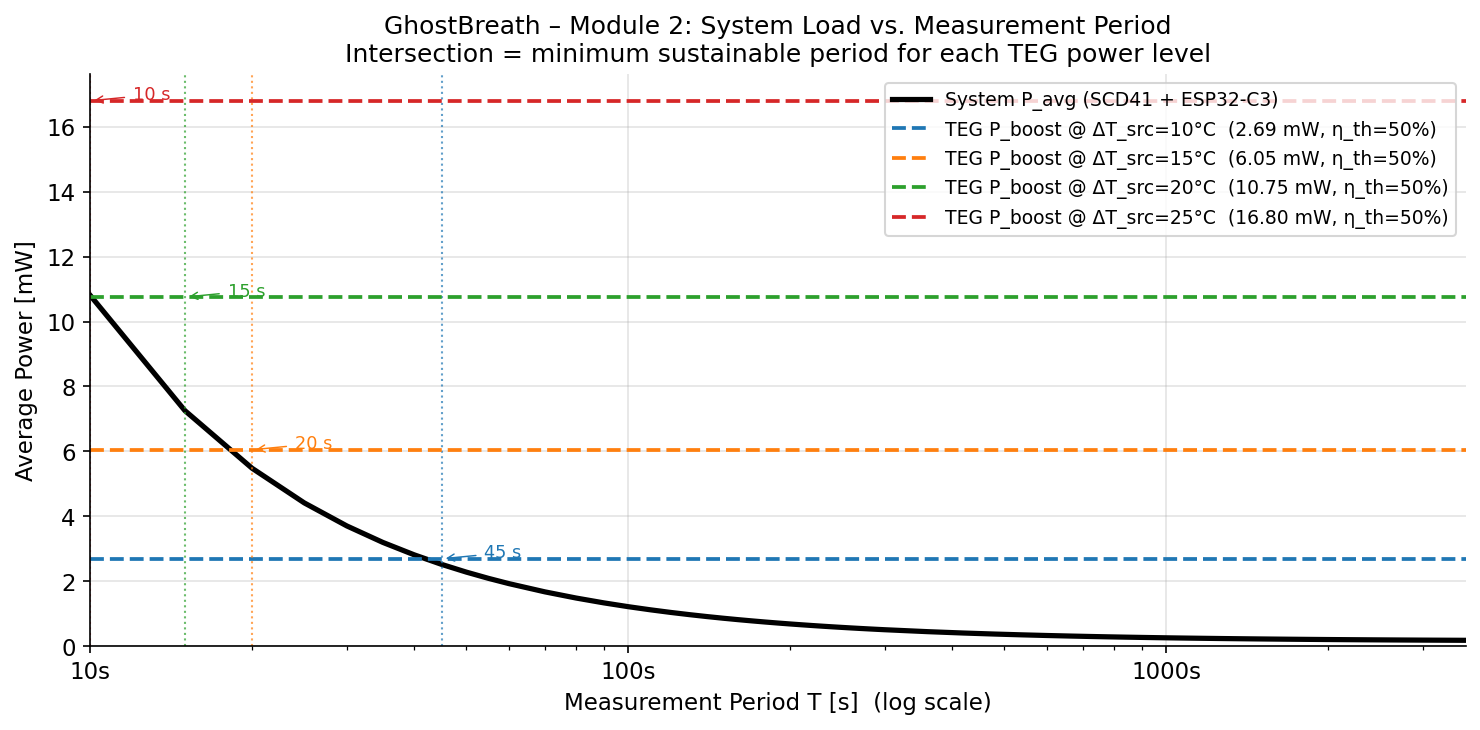

Saved: figures/02a_supercap_load_vs_period.png

System power at selected periods:
   T (s)    P_sys (mW)
------------------------
      30         3.701
      60         1.925
     120         1.037
     300         0.504
     600         0.326
    3600         0.178


In [4]:
T_periods = np.concatenate([
    np.arange(10, 60, 5),
    np.arange(60, 300, 10),
    np.arange(300, 3610, 60),
])

P_sys_mW = np.array([system_power_W(T) * 1e3 for T in T_periods])

# ── TEG realistic power at key ΔT_source ─────────────────────────────────────
key_dts   = [10, 15, 20, 25]      # source ΔT [°C]
colours_dt = [C_BLUE, C_ORANGE, C_GREEN, C_RED]

P_teg_mid_mW = [
    boost_output_power(max_power(COUPLING_MID * dt, N, alpha, R_int), eta_boost) * 1e3
    for dt in key_dts
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(T_periods, P_sys_mW, color='black', lw=2.5,
            label='System P_avg (SCD41 + ESP32-C3)')

for dt, p_teg, col in zip(key_dts, P_teg_mid_mW, colours_dt):
    ax.axhline(p_teg, color=col, lw=1.8, ls='--',
               label=f'TEG P_boost @ ΔT_src={dt}°C  ({p_teg:.2f} mW, η_th=50%)')
    # Mark the minimum sustainable period
    T_min = next((T for T, P in zip(T_periods, P_sys_mW) if P <= p_teg), np.inf)
    if T_min < np.inf:
        ax.axvline(T_min, color=col, lw=1.0, ls=':', alpha=0.7)
        ax.annotate(f'{T_min:.0f} s', xy=(T_min, p_teg),
                    xytext=(T_min * 1.2, p_teg + 0.03),
                    fontsize=8.5, color=col,
                    arrowprops=dict(arrowstyle='->', color=col, lw=0.7))

ax.set_xlabel('Measurement Period T [s]  (log scale)')
ax.set_ylabel('Average Power [mW]')
ax.set_title(
    'GhostBreath – Module 2: System Load vs. Measurement Period\n'
    'Intersection = minimum sustainable period for each TEG power level'
)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(T_periods[0], T_periods[-1])
ax.set_ylim(0, None)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}s'))

plt.tight_layout()
fig.savefig('figures/02a_supercap_load_vs_period.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/02a_supercap_load_vs_period.png")

# ── Print table ───────────────────────────────────────────────────────────────
print()
print(f"System power at selected periods:")
print(f"{'T (s)':>8}  {'P_sys (mW)':>12}")
print("-" * 24)
for T_sel in [30, 60, 120, 300, 600, 3600]:
    idx = np.argmin(np.abs(T_periods - T_sel))
    print(f"{T_sel:>8}  {P_sys_mW[idx]:>12.3f}")

---
## Step 3 — Charge Time from Empty to Operational

When the GhostBreath device is first clipped on, the supercapacitor starts at
V_min = 1.0 V (empty). It must charge to at least V_op = 1.5 V before the
system can wake up, and ideally to V_max = 2.7 V for maximum energy reserve.

$$t_{charge} = \frac{C (V_{max}^2 - V_{min}^2)}{2 P_{in}}$$

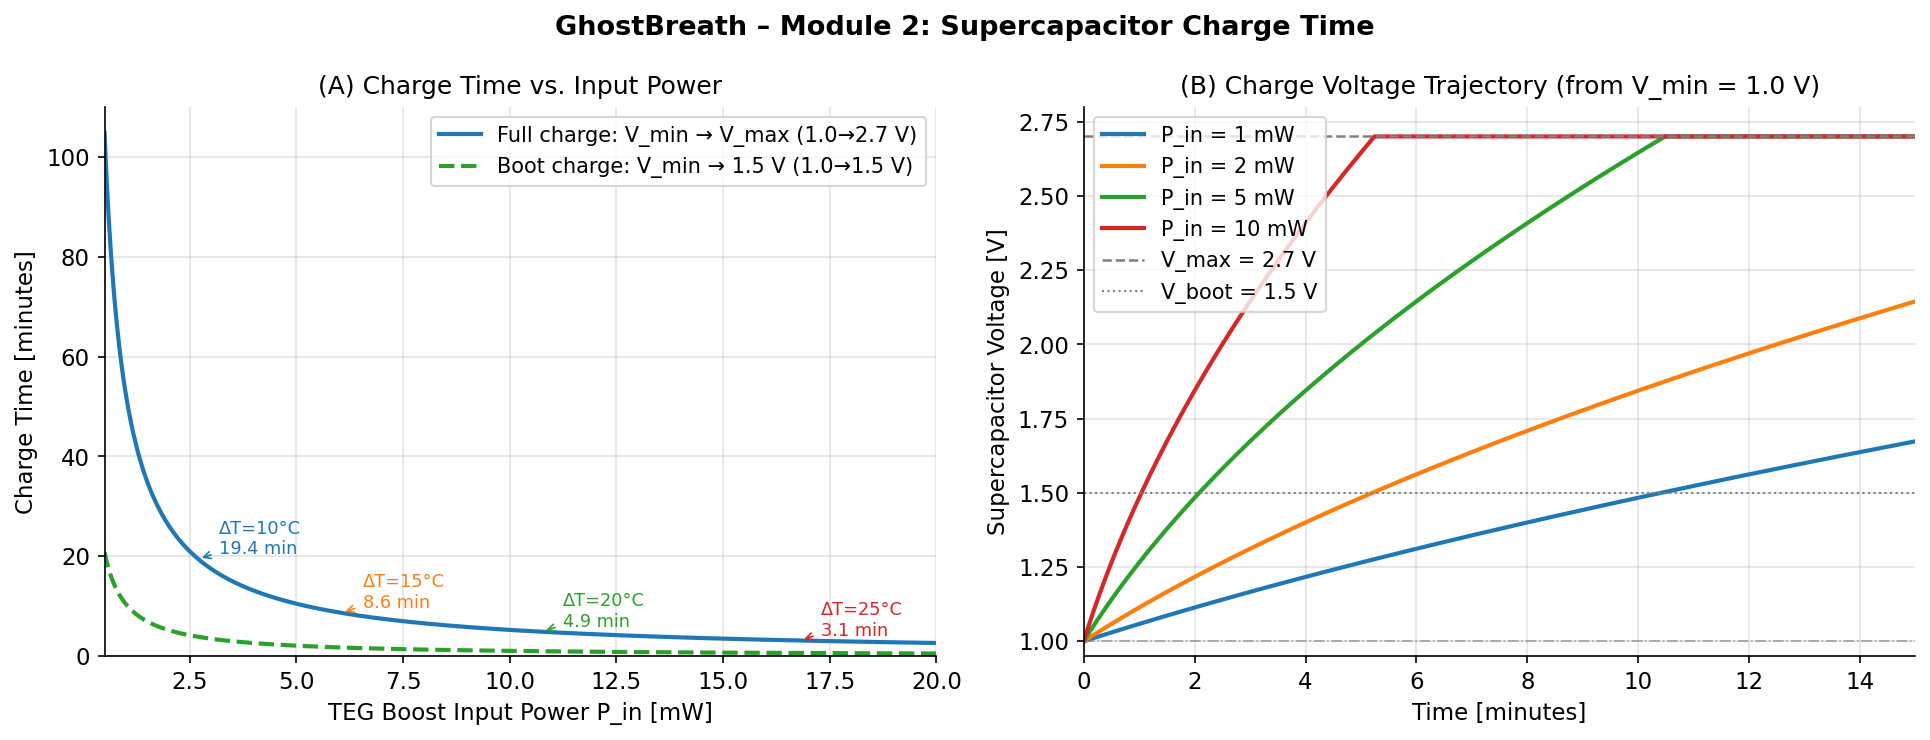

Saved: figures/02b_supercap_charge_time.png

Charge time at realistic TEG power levels (η_th=50%):
  ΔT_src      P_in    t_boot (1V→1.5V)    t_full (1V→2.7V)
------------------------------------------------------------
     10°C     2.69 mW             3.9 min            19.5 min
     15°C     6.05 mW             1.7 min             8.7 min
     20°C    10.75 mW             1.0 min             4.9 min
     25°C    16.80 mW             0.6 min             3.1 min


In [5]:
# ── Charge time vs. TEG input power ──────────────────────────────────────────
P_in_range_mW = np.linspace(0.5, 20, 400)   # [mW]
P_in_range_W  = P_in_range_mW * 1e-3

t_ch_full  = np.array([charge_time(C_sc, P, V_min, V_max, ESR) for P in P_in_range_W])
t_ch_boot  = np.array([charge_time(C_sc, P, V_min, 1.5,  ESR) for P in P_in_range_W])  # to 1.5V

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'GhostBreath – Module 2: Supercapacitor Charge Time',
    fontsize=13, fontweight='bold'
)

# ─── Panel A: Charge time vs P_in ─────────────────────────────────────────────
ax = axes[0]
ax.plot(P_in_range_mW, t_ch_full / 60,  color=C_BLUE,   lw=2,
        label=f'Full charge: V_min → V_max ({V_min}→{V_max} V)')
ax.plot(P_in_range_mW, t_ch_boot / 60,  color=C_GREEN,  lw=2, ls='--',
        label=f'Boot charge: V_min → 1.5 V ({V_min}→1.5 V)')

# Mark TEG P_boost at key ΔT (nominal 50% coupling)
for dt, p_teg, col in zip(key_dts, P_teg_mid_mW, colours_dt):
    idx = np.argmin(np.abs(P_in_range_mW - p_teg))
    t_f = t_ch_full[idx] / 60
    ax.annotate(
        f'ΔT={dt}°C\n{t_f:.1f} min',
        xy=(p_teg, t_f),
        xytext=(p_teg + 0.5, t_f + 1),
        fontsize=8.5, color=col,
        arrowprops=dict(arrowstyle='->', color=col, lw=0.8)
    )

ax.set_xlabel('TEG Boost Input Power P_in [mW]')
ax.set_ylabel('Charge Time [minutes]')
ax.set_title('(A) Charge Time vs. Input Power')
ax.legend()
ax.set_xlim(0.5, 20)
ax.set_ylim(0, None)

# ─── Panel B: Voltage trajectory for several P_in ─────────────────────────────
ax = axes[1]
t_sim = np.linspace(0, 900, 1000)  # 0–15 min
for P_mw, col in zip([1.0, 2.0, 5.0, 10.0], [C_BLUE, C_ORANGE, C_GREEN, C_RED]):
    V_t = voltage_vs_time_charge(C_sc, P_mw * 1e-3, V_min, t_sim, ESR)
    ax.plot(t_sim / 60, V_t, color=col, lw=2, label=f'P_in = {P_mw:.0f} mW')

ax.axhline(V_max, color='gray', lw=1.2, ls='--', label=f'V_max = {V_max} V')
ax.axhline(1.5,  color='gray', lw=1.0, ls=':',  label='V_boot = 1.5 V')
ax.axhline(V_min, color='gray', lw=0.8, ls='-.', alpha=0.7)

ax.set_xlabel('Time [minutes]')
ax.set_ylabel('Supercapacitor Voltage [V]')
ax.set_title('(B) Charge Voltage Trajectory (from V_min = 1.0 V)')
ax.legend()
ax.set_xlim(0, 15)
ax.set_ylim(V_min - 0.05, V_max + 0.1)

plt.tight_layout()
fig.savefig('figures/02b_supercap_charge_time.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/02b_supercap_charge_time.png")

# ── Print charge time table ───────────────────────────────────────────────────
print()
print(f"Charge time at realistic TEG power levels (η_th=50%):")
print(f"{'ΔT_src':>8}  {'P_in':>8}  {'t_boot (1V→1.5V)':>18}  {'t_full (1V→2.7V)':>18}")
print("-" * 60)
for dt in [10, 15, 20, 25]:
    p_mw = boost_output_power(max_power(COUPLING_MID*dt, N, alpha, R_int), eta_boost) * 1e3
    t_b  = charge_time(C_sc, p_mw*1e-3, V_min, 1.5, ESR)
    t_f  = charge_time(C_sc, p_mw*1e-3, V_min, V_max, ESR)
    print(f"{dt:>7}°C  {p_mw:>7.2f} mW  {t_b/60:>14.1f} min  {t_f/60:>14.1f} min")

---
## Step 4 — Duty-Cycle Analysis

For a given TEG input power, find the **minimum measurement period** that keeps
the system energy-neutral (P_load ≤ P_in). Longer periods → lower average power.

This directly answers: *"How often can GhostBreath take a CO₂ reading?"*

In [6]:
# ── Power levels: realistic TEG output across coupling range ─────────────────
P_in_test_mW = []
labels_test  = []
for dt in [10, 12, 15, 20, 25]:
    for eta, tag in [(COUPLING_LO, '40%'), (COUPLING_MID, '50%'), (COUPLING_HI, '60%')]:
        p = boost_output_power(max_power(eta*dt, N, alpha, R_int), eta_boost) * 1e3
        P_in_test_mW.append(p)
        labels_test.append(f'ΔT={dt}°C η={tag}')

dc = duty_cycle_analysis(
    [p*1e-3 for p in P_in_test_mW],
    C_sc=C_sc, V_max=V_max, V_min=V_min, ESR=ESR
)

print("=" * 80)
print("DUTY-CYCLE ANALYSIS — Min measurement period for energy-neutral operation")
print("=" * 80)
print(f"{'Scenario':>22}  {'P_in':>8}  {'P_load':>8}  {'T_min':>8}  {'E_usable':>10}  {'t_charge':>10}")
print(f"{'':>22}  {'(mW)':>8}  {'(mW)':>8}  {'(s)':>8}  {'(mJ)':>10}  {'(min)':>10}")
print("-" * 80)
for i, lbl in enumerate(labels_test):
    p_in   = dc['P_in_mW'][i]
    t_min  = dc['T_min_s'][i]
    p_load = dc['P_load_mW'][i]
    e_use  = dc['E_usable_mJ'][i]
    t_ch   = dc['t_charge_s'][i]
    t_ch_m = t_ch / 60 if t_ch < np.inf else np.inf
    t_str  = f'{t_min:>8.0f}' if t_min < np.inf else '     ∞  '
    tc_str = f'{t_ch_m:>10.1f}' if t_ch_m < np.inf else '       ∞'
    print(f"{lbl:>22}  {p_in:>8.2f}  {p_load:>8.3f}  {t_str}  {e_use:>10.2f}  {tc_str}")
print("=" * 80)

DUTY-CYCLE ANALYSIS — Min measurement period for energy-neutral operation
              Scenario      P_in    P_load     T_min    E_usable    t_charge
                            (mW)      (mW)       (s)        (mJ)       (min)
--------------------------------------------------------------------------------
         ΔT=10°C η=40%      1.72     1.671        70     3145.00        30.5
         ΔT=10°C η=50%      2.69     2.517        45     3145.00        19.5
         ΔT=10°C η=60%      3.87     3.701        30     3145.00        13.5
         ΔT=12°C η=40%      2.48     2.280        50     3145.00        21.2
         ΔT=12°C η=50%      3.87     3.701        30     3145.00        13.5
         ΔT=12°C η=60%      5.57     5.478        20     3145.00         9.4
         ΔT=15°C η=40%      3.87     3.701        30     3145.00        13.5
         ΔT=15°C η=50%      6.05     5.478        20     3145.00         8.7
         ΔT=15°C η=60%      8.71     7.254        15     3145.00         6.

---
## Step 5 — Minimum Capacitance for Startup

The supercapacitor must hold enough energy to power one complete measurement +
BLE transmission if the TEG is momentarily unavailable (e.g., laptop enters
sleep and exhaust cools briefly).

One full session (SCD41 meas + BLE TX at full power, ignoring sleep phase):

$$E_{session} = P_{meas} \cdot t_{meas} + P_{tx} \cdot t_{tx}$$

One active session (SCD41 meas + BLE TX):
  P_meas  = 10.91 mW  for 5.0 s
  P_tx    = 264.13 mW  for 0.20 s
  E_session = 107.359 mJ

Default 1 F supercap usable energy: 3145.00 mJ
→ Can sustain 29.3 full sessions without any TEG input

Minimum C for one session: 34.14 mF  (34136.4 µF)
  → 1 F supercap provides 29× safety margin


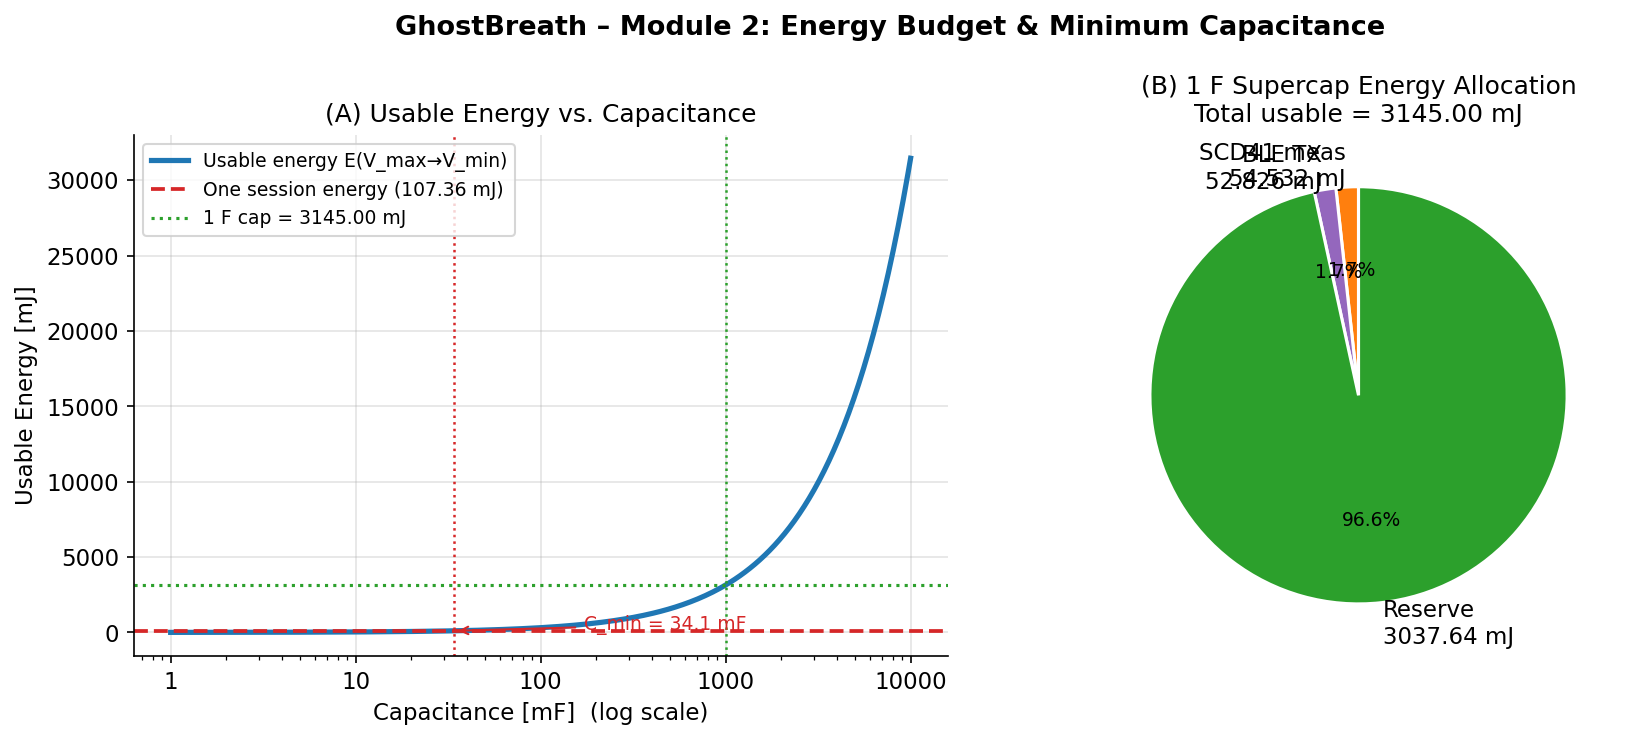

Saved: figures/02c_supercap_energy_budget.png


In [7]:
sl = SYSTEM_LOAD

# Energy for one active session (worst case: measurement + BLE TX, no sleep phase)
P_meas = (sl['I_scd41_active_A'] + sl['I_mcu_sleep_A']) * sl['V_sys']   # [W]
P_tx   = (sl['I_mcu_active_A']   + sl['I_scd41_idle_A']) * sl['V_sys']  # [W]

E_session_J = P_meas * sl['t_scd41_meas_s'] + P_tx * sl['t_mcu_active_s']
E_session_mJ = E_session_J * 1e3

# How many sessions can the default 1 F supercap sustain?
n_sessions = E_use_J / E_session_J

# Minimum capacitance for one complete session
C_min_session_F = min_capacitance(E_session_J, V_max, V_min)
C_min_session_mF = C_min_session_F * 1e3

print("One active session (SCD41 meas + BLE TX):")
print(f"  P_meas  = {P_meas*1e3:.2f} mW  for {sl['t_scd41_meas_s']:.1f} s")
print(f"  P_tx    = {P_tx*1e3:.2f} mW  for {sl['t_mcu_active_s']:.2f} s")
print(f"  E_session = {E_session_J*1e3:.3f} mJ")
print()
print(f"Default 1 F supercap usable energy: {E_use_mJ:.2f} mJ")
print(f"→ Can sustain {n_sessions:.1f} full sessions without any TEG input")
print()
print(f"Minimum C for one session: {C_min_session_mF:.2f} mF  ({C_min_session_F*1e6:.1f} µF)")
print(f"  → 1 F supercap provides {1/C_min_session_F:.0f}× safety margin")

# ── Plot: Energy budget breakdown ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'GhostBreath – Module 2: Energy Budget & Minimum Capacitance',
    fontsize=13, fontweight='bold'
)

# Panel A: Usable energy vs. capacitance
ax = axes[0]
C_range = np.logspace(-3, 1, 300)   # 1 mF to 10 F
E_range_mJ = usable_energy(C_range, V_max, V_min) * 1e3
ax.semilogx(C_range * 1e3, E_range_mJ, color=C_BLUE, lw=2.5,
            label='Usable energy E(V_max→V_min)')
ax.axhline(E_session_mJ, color=C_RED, lw=1.8, ls='--',
           label=f'One session energy ({E_session_mJ:.2f} mJ)')
ax.axhline(E_use_mJ, color=C_GREEN, lw=1.5, ls=':',
           label=f'1 F cap = {E_use_mJ:.2f} mJ')
ax.axvline(C_min_session_mF, color=C_RED, lw=1.2, ls=':')
ax.axvline(1000, color=C_GREEN, lw=1.2, ls=':')
ax.annotate(f'C_min = {C_min_session_mF:.1f} mF',
            xy=(C_min_session_mF, E_session_mJ),
            xytext=(C_min_session_mF * 5, E_session_mJ * 1.5),
            fontsize=9, color=C_RED,
            arrowprops=dict(arrowstyle='->', color=C_RED))
ax.set_xlabel('Capacitance [mF]  (log scale)')
ax.set_ylabel('Usable Energy [mJ]')
ax.set_title('(A) Usable Energy vs. Capacitance')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

# Panel B: Energy pie chart
ax = axes[1]
E_meas_mJ = P_meas  * sl['t_scd41_meas_s'] * 1e3
E_tx_mJ   = P_tx    * sl['t_mcu_active_s']  * 1e3
E_spare_mJ = E_use_mJ - E_meas_mJ - E_tx_mJ

sizes  = [E_meas_mJ, E_tx_mJ, max(E_spare_mJ, 0)]
labels = [
    f'SCD41 meas\n{E_meas_mJ:.3f} mJ',
    f'BLE TX\n{E_tx_mJ:.3f} mJ',
    f'Reserve\n{max(E_spare_mJ,0):.2f} mJ',
]
colours_pie = [C_ORANGE, C_PURPLE, C_GREEN]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colours_pie,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title(f'(B) 1 F Supercap Energy Allocation\n'
             f'Total usable = {E_use_mJ:.2f} mJ')

plt.tight_layout()
fig.savefig('figures/02c_supercap_energy_budget.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/02c_supercap_energy_budget.png")

---
## Step 6 — Time-Domain Simulation: Charge then Discharge

Simulate the supercapacitor voltage over time for two phases:
1. **Charging phase**: TEG on, load off → V rises from V_min to V_max
2. **Operating phase**: TEG on, load on → net charge/discharge depending on balance

Show results for the nominal (ΔT_src = 15 °C, η_th = 50 %) scenario.

Nominal scenario:
  ΔT_src = 15.0 °C,  η_th = 50%
  P_in   = 6.05 mW
  T_meas = 120 s → P_load_avg = 1.037 mW
  Net:   charging  (ΔP = +5.012 mW)


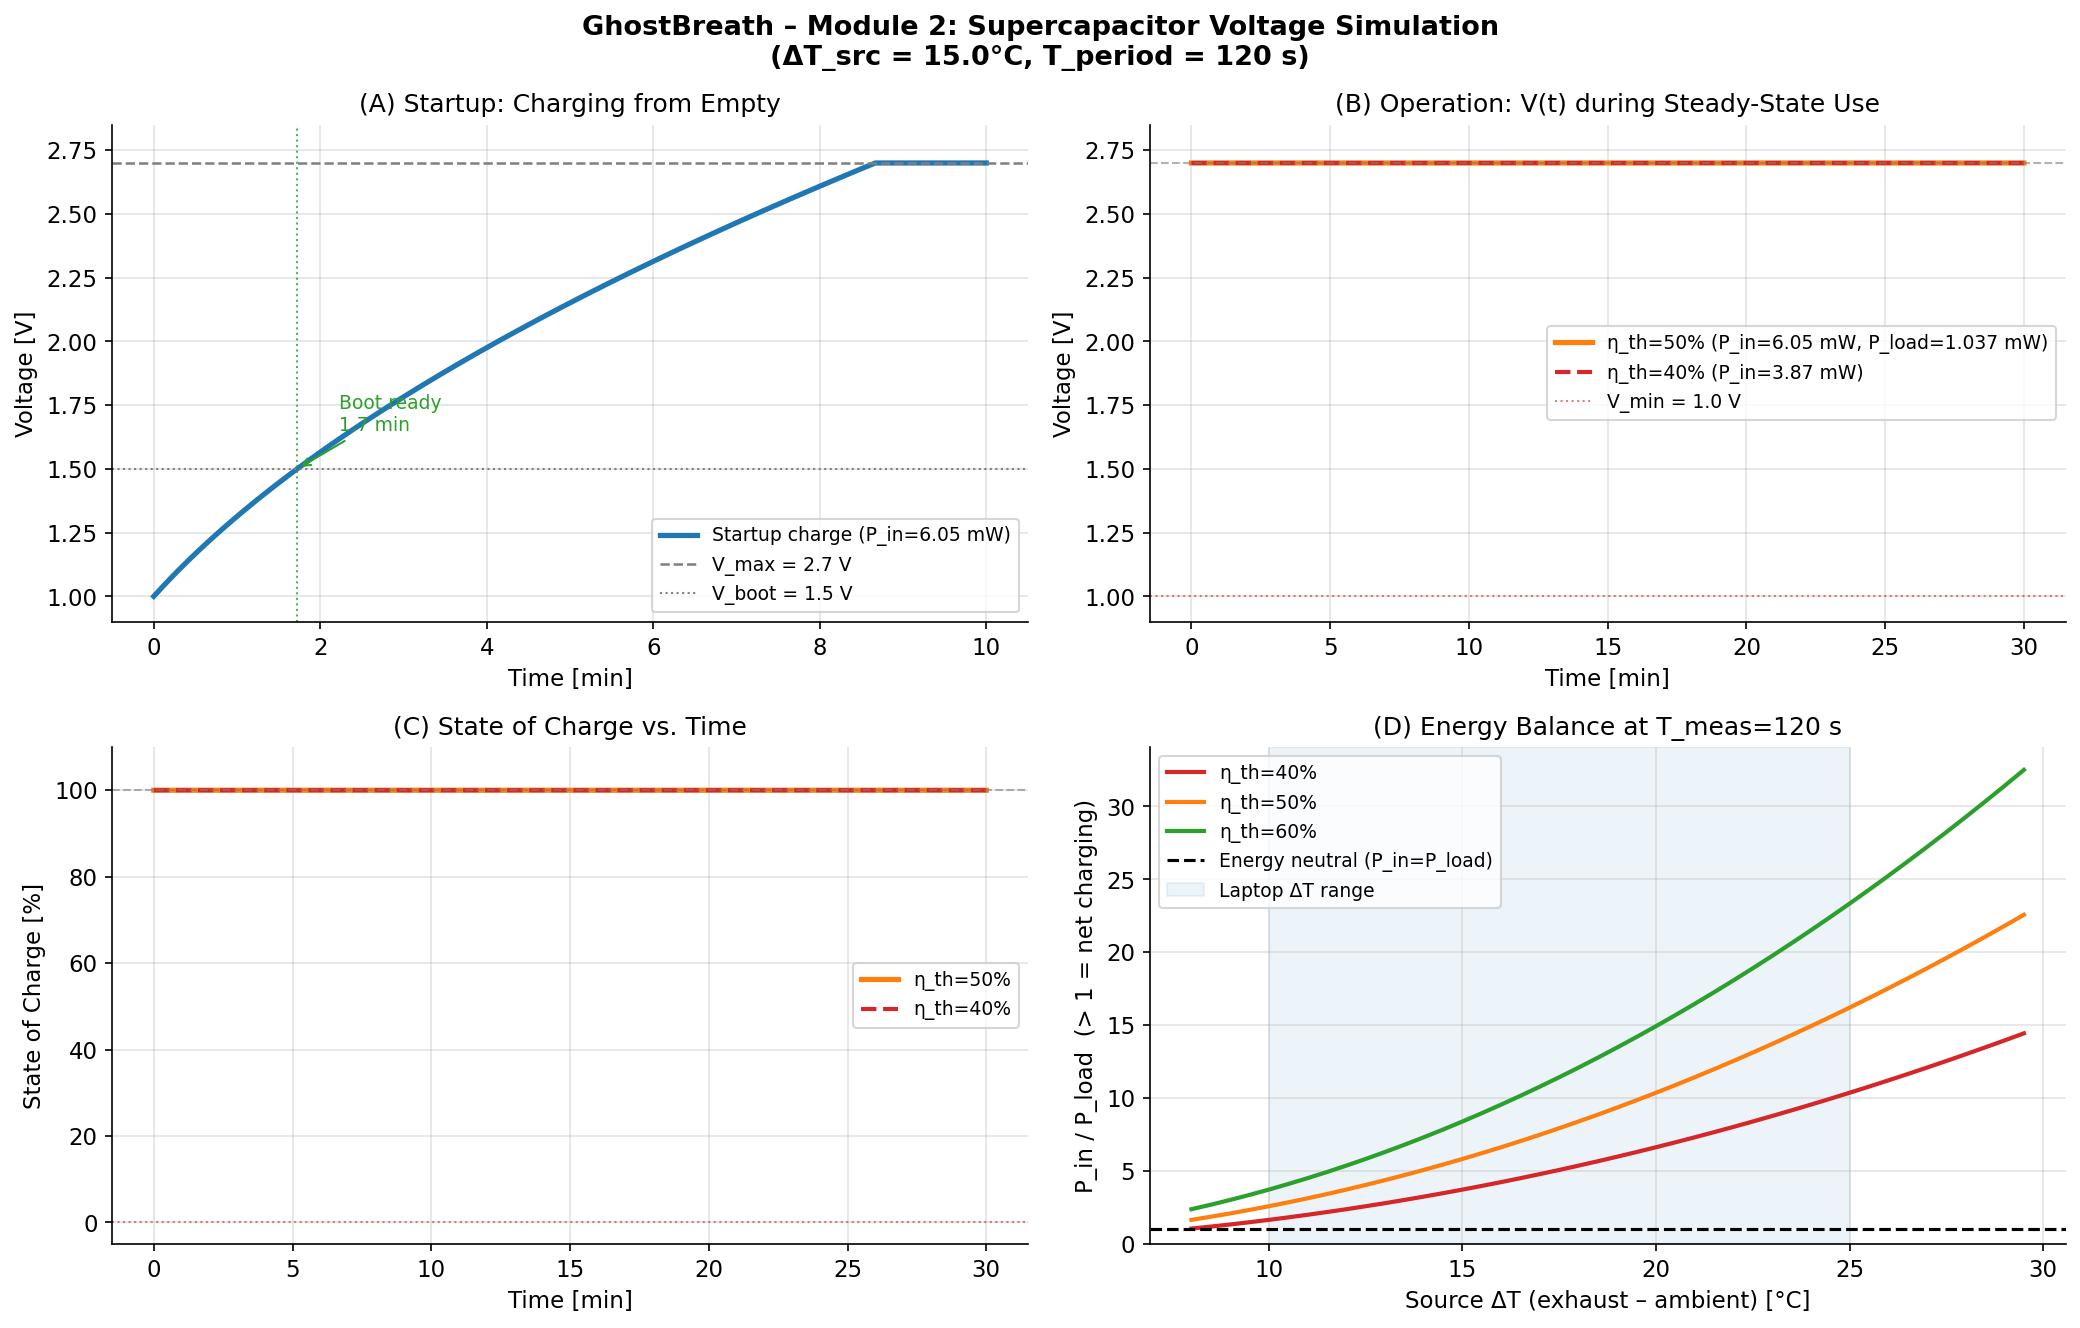

Saved: figures/02d_supercap_simulation.png


In [8]:
# ── Nominal operating scenario ─────────────────────────────────────────────────
DT_NOM   = 15.0                    # source ΔT [°C]
P_in_nom = boost_output_power(
    max_power(COUPLING_MID * DT_NOM, N, alpha, R_int), eta_boost
)  # [W]

T_period_nom = 120.0               # measurement every 120 s
P_load_nom   = system_power_W(T_period_nom)   # [W]

print(f"Nominal scenario:")
print(f"  ΔT_src = {DT_NOM} °C,  η_th = {COUPLING_MID*100:.0f}%")
print(f"  P_in   = {P_in_nom*1e3:.2f} mW")
print(f"  T_meas = {T_period_nom:.0f} s → P_load_avg = {P_load_nom*1e3:.3f} mW")
print(f"  Net:   {'charging' if P_in_nom > P_load_nom else 'discharging'}  "
      f"(ΔP = {(P_in_nom - P_load_nom)*1e3:+.3f} mW)")

# Phase 1: charge from empty (load off)
t1 = np.linspace(0, 600, 2000)     # 0–10 min
V1 = voltage_vs_time_charge(C_sc, P_in_nom, V_min, t1, ESR)

# Phase 2: operate (load on + TEG on), starting from V_max
t2_rel = np.linspace(0, 1800, 3000)  # 0–30 min
sim2 = simulate(
    C_sc, P_in_nom, P_load_nom,
    V_start=V_max, V_max=V_max, V_min=V_min,
    ESR=ESR, dt_s=0.5, t_max_s=1800.0
)

# Phase 3: what if TEG drops to 40% coupling (worst case)?
P_in_low = boost_output_power(
    max_power(COUPLING_LO * DT_NOM, N, alpha, R_int), eta_boost
)
sim3 = simulate(
    C_sc, P_in_low, P_load_nom,
    V_start=V_max, V_max=V_max, V_min=V_min,
    ESR=ESR, dt_s=0.5, t_max_s=1800.0
)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    f'GhostBreath – Module 2: Supercapacitor Voltage Simulation\n'
    f'(ΔT_src = {DT_NOM}°C, T_period = {T_period_nom:.0f} s)',
    fontsize=13, fontweight='bold'
)

# ─ A: Startup charge ──────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(t1 / 60, V1, color=C_BLUE, lw=2.5, label=f'Startup charge (P_in={P_in_nom*1e3:.2f} mW)')
ax.axhline(V_max, color=C_GRAY, lw=1.2, ls='--', label=f'V_max = {V_max} V')
ax.axhline(1.5,  color=C_GRAY, lw=1.0, ls=':',  label='V_boot = 1.5 V')
t_boot_s = charge_time(C_sc, P_in_nom, V_min, 1.5, ESR)
ax.axvline(t_boot_s/60, color=C_GREEN, lw=1.0, ls=':', alpha=0.8)
ax.annotate(f'Boot ready\n{t_boot_s/60:.1f} min',
            xy=(t_boot_s/60, 1.5),
            xytext=(t_boot_s/60 + 0.5, 1.65),
            fontsize=9, color=C_GREEN,
            arrowprops=dict(arrowstyle='->', color=C_GREEN))
ax.set_xlabel('Time [min]')
ax.set_ylabel('Voltage [V]')
ax.set_title('(A) Startup: Charging from Empty')
ax.legend(fontsize=9)
ax.set_ylim(0.9, V_max + 0.15)

# ─ B: Normal operation (nominal coupling) ─────────────────────────────────────
ax = axes[0, 1]
t2_min = sim2['t'] / 60
ax.plot(t2_min, sim2['V'], color=C_ORANGE, lw=2.5,
        label=f'η_th=50% (P_in={P_in_nom*1e3:.2f} mW, P_load={P_load_nom*1e3:.3f} mW)')
ax.plot(sim3['t']/60, sim3['V'], color=C_RED, lw=2, ls='--',
        label=f'η_th=40% (P_in={P_in_low*1e3:.2f} mW)')
ax.axhline(V_max, color=C_GRAY, lw=1.0, ls='--', alpha=0.6)
ax.axhline(V_min, color=C_RED,  lw=1.0, ls=':',  alpha=0.6, label=f'V_min = {V_min} V')
ax.set_xlabel('Time [min]')
ax.set_ylabel('Voltage [V]')
ax.set_title('(B) Operation: V(t) during Steady-State Use')
ax.legend(fontsize=9)
ax.set_ylim(0.9, V_max + 0.15)

# ─ C: State of Charge ─────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(t2_min, sim2['SoC'] * 100, color=C_ORANGE, lw=2.5, label='η_th=50%')
ax.plot(sim3['t']/60, sim3['SoC'] * 100, color=C_RED, lw=2, ls='--', label='η_th=40%')
ax.axhline(100, color=C_GRAY, lw=1.0, ls='--', alpha=0.6)
ax.axhline(0,   color=C_RED,  lw=1.0, ls=':',  alpha=0.6)
ax.set_xlabel('Time [min]')
ax.set_ylabel('State of Charge [%]')
ax.set_title('(C) State of Charge vs. Time')
ax.legend(fontsize=9)
ax.set_ylim(-5, 110)

# ─ D: SoC scan over ΔT and coupling ─────────────────────────────────────────
ax = axes[1, 1]
dt_scan = np.arange(8, 30, 0.5)
T_fix   = 120.0   # fixed measurement period 120 s
P_load_fixed = system_power_W(T_fix)
for eta, col, lbl in [
        (COUPLING_LO,  C_RED,    '40%'),
        (COUPLING_MID, C_ORANGE, '50%'),
        (COUPLING_HI,  C_GREEN,  '60%'),
]:
    P_in_scan = boost_output_power(
        max_power(eta * dt_scan, N, alpha, R_int), eta_boost
    )
    # Net power ratio: P_in / P_load → > 1 means charging
    ratio = P_in_scan / P_load_fixed
    ax.plot(dt_scan, ratio, color=col, lw=2, label=f'η_th={lbl}')

ax.axhline(1.0, color='black', lw=1.5, ls='--', label='Energy neutral (P_in=P_load)')
ax.axvspan(10, 25, alpha=0.08, color=C_BLUE, label='Laptop ΔT range')
ax.set_xlabel('Source ΔT (exhaust – ambient) [°C]')
ax.set_ylabel('P_in / P_load  (> 1 = net charging)')
ax.set_title(f'(D) Energy Balance at T_meas={T_fix:.0f} s')
ax.legend(fontsize=9)
ax.set_ylim(0, None)

plt.tight_layout()
fig.savefig('figures/02d_supercap_simulation.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/02d_supercap_simulation.png")

---
## Step 7 — Discharge-only Scenario (TEG Fails)

If the laptop enters sleep mode or is moved away from the vent, the TEG
output may drop to zero. The supercapacitor must then sustain the system
long enough to complete at least one final CO₂ reading and BLE transmission.

How long can the device run on supercap energy alone?

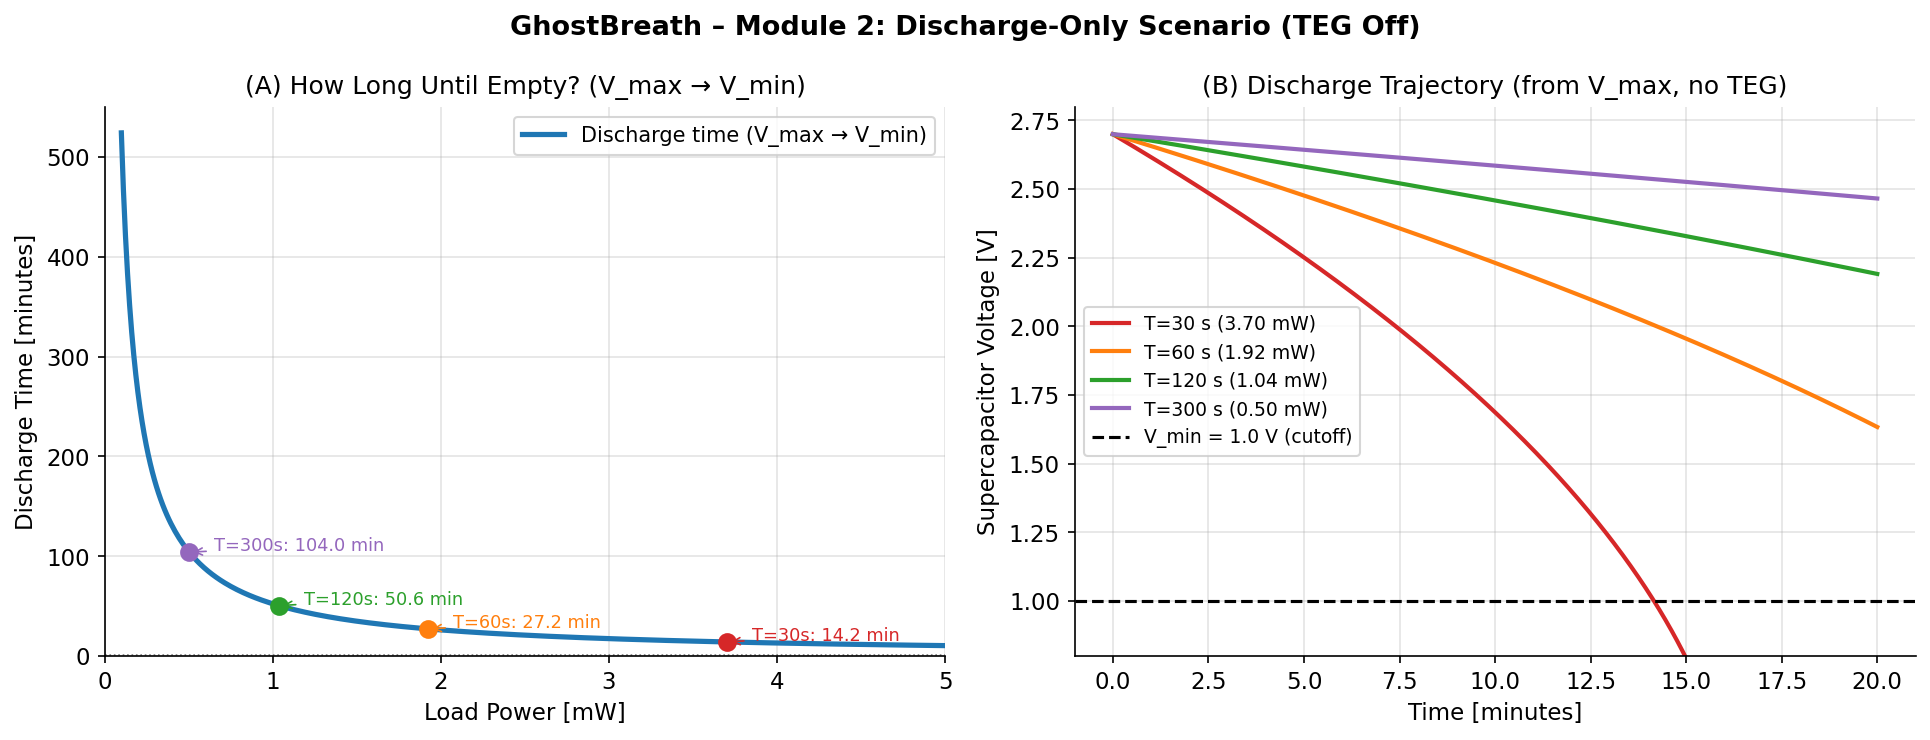

Saved: figures/02e_supercap_discharge.png

Discharge survivability (V_max → V_min, TEG off):
  T_meas      P_load     t_discharge    Sessions
--------------------------------------------------
     30 s      3.701 mW          14.2 min       28.3
     60 s      1.925 mW          27.2 min       27.2
    120 s      1.037 mW          50.6 min       25.3
    300 s      0.504 mW         104.0 min       20.8
    600 s      0.326 mW         160.7 min       16.1


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'GhostBreath – Module 2: Discharge-Only Scenario (TEG Off)',
    fontsize=13, fontweight='bold'
)

# ─ Panel A: Discharge time vs load power ─────────────────────────────────────
ax = axes[0]
P_load_scan = np.linspace(0.1, 5.0, 400)   # [mW]
t_dis_full  = np.array([
    discharge_time(C_sc, P*1e-3, V_max, V_min, ESR)
    for P in P_load_scan
])

ax.plot(P_load_scan, t_dis_full / 60, color=C_BLUE, lw=2.5,
        label='Discharge time (V_max → V_min)')

# Mark session energy line
ax.axhline(E_session_J / (P_load_scan.mean() * 1e-3) / 60,
           color=C_GRAY, lw=0.8, ls=':')

# Mark key load points
for T_sel, col in [(30, C_RED), (60, C_ORANGE), (120, C_GREEN), (300, C_PURPLE)]:
    P_l = system_power_W(T_sel)
    t_d = discharge_time(C_sc, P_l, V_max, V_min, ESR)
    ax.annotate(
        f'T={T_sel}s: {t_d/60:.1f} min',
        xy=(P_l*1e3, t_d/60),
        xytext=(P_l*1e3 + 0.15, t_d/60 + 1),
        fontsize=8.5, color=col,
        arrowprops=dict(arrowstyle='->', color=col, lw=0.8)
    )
    ax.plot(P_l*1e3, t_d/60, 'o', color=col, ms=8)

ax.set_xlabel('Load Power [mW]')
ax.set_ylabel('Discharge Time [minutes]')
ax.set_title('(A) How Long Until Empty? (V_max → V_min)')
ax.legend()
ax.set_xlim(0, 5)
ax.set_ylim(0, None)

# ─ Panel B: Voltage trajectory during discharge ───────────────────────────────
ax = axes[1]
t_dis_sim = np.linspace(0, 1200, 2000)   # 0–20 min

for T_sel, col, lbl in [
        (30,  C_RED,    'T=30 s'),
        (60,  C_ORANGE, 'T=60 s'),
        (120, C_GREEN,  'T=120 s'),
        (300, C_PURPLE, 'T=300 s'),
]:
    P_l = system_power_W(T_sel)
    V_dis = voltage_vs_time_discharge(C_sc, P_l, V_max, t_dis_sim, ESR)
    ax.plot(t_dis_sim / 60, V_dis, color=col, lw=2, label=f'{lbl} ({P_l*1e3:.2f} mW)')

ax.axhline(V_min, color='black', lw=1.5, ls='--', label=f'V_min = {V_min} V (cutoff)')
ax.set_xlabel('Time [minutes]')
ax.set_ylabel('Supercapacitor Voltage [V]')
ax.set_title('(B) Discharge Trajectory (from V_max, no TEG)')
ax.legend(fontsize=9)
ax.set_ylim(0.8, V_max + 0.1)

plt.tight_layout()
fig.savefig('figures/02e_supercap_discharge.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/02e_supercap_discharge.png")

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print("Discharge survivability (V_max → V_min, TEG off):")
print(f"{'T_meas':>8}  {'P_load':>10}  {'t_discharge':>14}  {'Sessions':>10}")
print("-" * 50)
for T_sel in [30, 60, 120, 300, 600]:
    P_l  = system_power_W(T_sel)
    t_d  = discharge_time(C_sc, P_l, V_max, V_min, ESR)
    n_s  = t_d / T_sel if T_sel > 0 else 0
    print(f"{T_sel:>7} s  {P_l*1e3:>9.3f} mW  {t_d/60:>12.1f} min  {n_s:>9.1f}")

---
## Summary and Conclusions

In [10]:
print("=" * 68)
print("MODULE 2 RESULTS — GhostBreath Supercapacitor Energy Buffer")
print("=" * 68)

print(f"""
Supercapacitor (1 F EDLC, V_max=2.7V, V_min=1.0V):
  Usable energy       : {E_use_mJ:.2f} mJ
  ESR                 : {ESR*1000:.0f} mΩ

System Load (SCD41 + ESP32-C3, duty-cycled at 3.3 V):
  One active session  : {E_session_mJ:.3f} mJ  ({n_sessions:.1f} sessions from full cap)
  Avg power (T=120 s) : {system_power_W(120)*1e3:.3f} mW
  Avg power (T=60 s)  : {system_power_W(60)*1e3:.3f} mW

TEG → Boost input (η_th=50%, ΔT_src=15°C):
  P_in                : {boost_output_power(max_power(COUPLING_MID*15,N,alpha,R_int),eta_boost)*1e3:.2f} mW
  Startup charge time : {charge_time(C_sc, boost_output_power(max_power(COUPLING_MID*15,N,alpha,R_int),eta_boost), V_min, V_max, ESR)/60:.1f} min
  Boot-ready (1.5V)   : {charge_time(C_sc, boost_output_power(max_power(COUPLING_MID*15,N,alpha,R_int),eta_boost), V_min, 1.5, ESR)/60:.1f} min
""")

print("Sustainable measurement periods (energy-neutral):")
print(f"{'Scenario':>25}  {'P_in (mW)':>10}  {'T_min (s)':>10}  {'Viable?':>8}")
print("-" * 60)
for dt in [10, 15, 20, 25]:
    for eta, tag in [(COUPLING_LO,'40%'), (COUPLING_MID,'50%'), (COUPLING_HI,'60%')]:
        p_mw = boost_output_power(max_power(eta*dt,N,alpha,R_int),eta_boost)*1e3
        T_min = min_period_for_power(p_mw*1e-3)
        ok    = '✓' if T_min < np.inf else '✗'
        T_str = f'{T_min:.0f}' if T_min < np.inf else '  N/A'
        print(f"{'ΔT='+str(dt)+'°C η='+tag:>25}  {p_mw:>10.2f}  {T_str:>10}  {ok:>8}")

print("=" * 68)
print("\nConclusion:")
print("  ✓ 1 F supercap is sufficient for GhostBreath energy buffer")
print("  ✓ With ΔT_src=15°C (η_th=50%): T_min ≈ 60–120 s is sustainable")
print("  ✓ Startup boot takes < 5 min — acceptable cold-start time")
print("  ✓ Discharge survival: > 5 min at T=120 s duty cycle")
print("\nNext: Module 3 — CO₂ Room Buildup Model")

MODULE 2 RESULTS — GhostBreath Supercapacitor Energy Buffer

Supercapacitor (1 F EDLC, V_max=2.7V, V_min=1.0V):
  Usable energy       : 3145.00 mJ
  ESR                 : 50 mΩ

System Load (SCD41 + ESP32-C3, duty-cycled at 3.3 V):
  One active session  : 107.359 mJ  (29.3 sessions from full cap)
  Avg power (T=120 s) : 1.037 mW
  Avg power (T=60 s)  : 1.925 mW

TEG → Boost input (η_th=50%, ΔT_src=15°C):
  P_in                : 6.05 mW
  Startup charge time : 8.7 min
  Boot-ready (1.5V)   : 1.7 min

Sustainable measurement periods (energy-neutral):
                 Scenario   P_in (mW)   T_min (s)   Viable?
------------------------------------------------------------
            ΔT=10°C η=40%        1.72          68         ✓
            ΔT=10°C η=50%        2.69          42         ✓
            ΔT=10°C η=60%        3.87          29         ✓
            ΔT=15°C η=40%        3.87          29         ✓
            ΔT=15°C η=50%        6.05          19         ✓
            ΔT=15°C η=60